In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
from sklearn.metrics import(
 accuracy_score,
 precision_score,
 recall_score,f1_score)



In [5]:
train_data=fetch_20newsgroups(
    subset="train",
    remove=("header","footers","quotes")
)


In [8]:
test_data=fetch_20newsgroups(
    subset="test",
    remove=("header","footers","quotes")
)

In [9]:
x_train_text=train_data.data
y_train=train_data.target

x_test_text=test_data.data
y_test=test_data.target

class_names=train_data.target_names


In [10]:
print("training document :",len(x_train_text))
print("testing documents:",len(x_test_text))
print("number of classes:",len(class_names))
      

training document : 11314
testing documents: 7532
number of classes: 20


In [37]:
vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2
)


x_train = vectorizer.fit_transform(x_train_text)

x_test = vectorizer.transform(x_test_text)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)



Training shape: (11314, 47541)
Testing shape: (7532, 47541)


In [33]:
mnb = MultinomialNB()

mnb.fit(
    x_train,
    y_train
)

y_pred_mnb = mnb.predict(
    x_test
)



In [34]:
binary_vectorizer =CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
x_train_binary=binary_vectorizer.fit_transform(
    x_train_text)
x_test_binary=binary_vectorizer.fit_transform(
    x_test_text)

In [35]:
bnb = BernoulliNB()

bnb.fit(
    x_train,
    y_train
)

y_pred_bnb = bnb.predict(
    x_test
)



In [40]:
results = pd.DataFrame({
    "Model": [
        "Multinomial NB",
        "Bernoulli NB"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_mnb),
        accuracy_score(y_test, y_pred_bnb)
    ],

    "Precision": [
        precision_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
        precision_score(
            y_test,
            y_pred_bnb,
            average="macro"
        )
    ],

    "Recall": [
        recall_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
        recall_score(
            y_test,
            y_pred_bnb,
            average="macro"
        )
    ],

    "F1 Score": [
        f1_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
        f1_score(
            y_test,
            y_pred_bnb,
            average="macro"
        )
    ]
})

results


,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial NB,0.754381,0.739647,0.745782,0.728723
1,Bernoulli NB,0.583510,0.691823,0.567435,0.554255


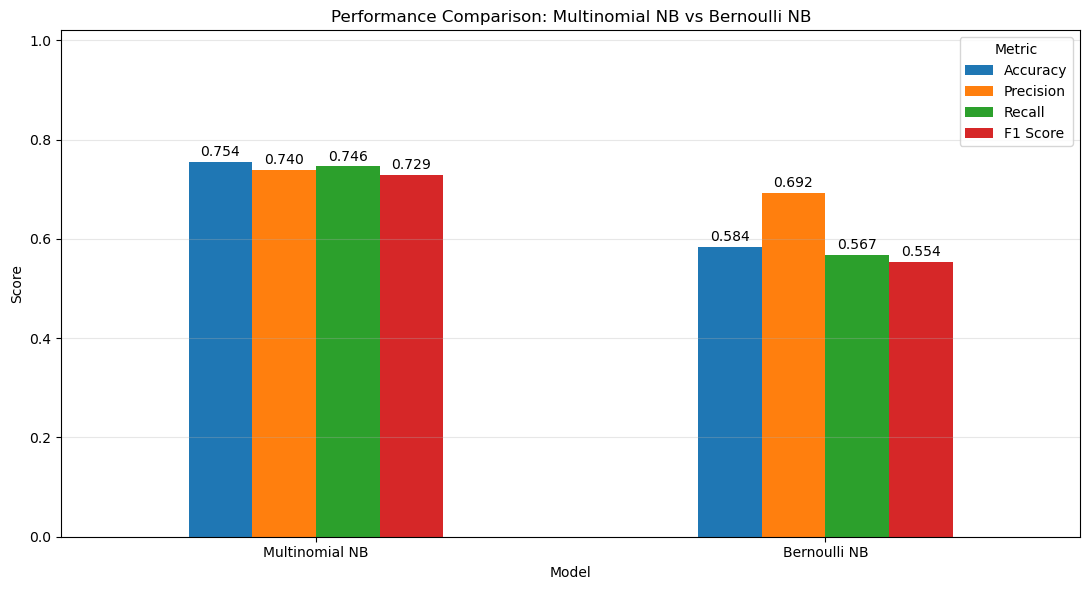

In [46]:
results_metrics=results[
["Model","Accuracy","Precision","Recall","F1 Score"]
]
ax=results_metrics.set_index("Model").plot(
kind="bar",
figsize=(11,6)
)
plt.title(
"Performance Comparison: Multinomial NB vs Bernoulli NB"
)
plt.xlabel("Model")
plt.ylabel("Score")

plt.ylim(0,1.02)

plt.xticks(rotation=0)

plt.legend(title="Metric")
plt.grid(
axis="y",
alpha=0.3
)
for container in ax.containers:
  ax.bar_label(
   container,
   fmt= "%.3f",
   padding=2
)

plt.tight_layout()
plt.show()